In [1]:
import numpy as np 
from scipy.optimize import curve_fit 
import matplotlib.pyplot as plt 
import pandas as pd

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [3]:
tau = pd.read_csv("../data/tau_data.csv")["Actual Tau?"].to_numpy()
N = pd.read_csv("../data/tau_data.csv")["Coincident Counts"].to_numpy() * 1000

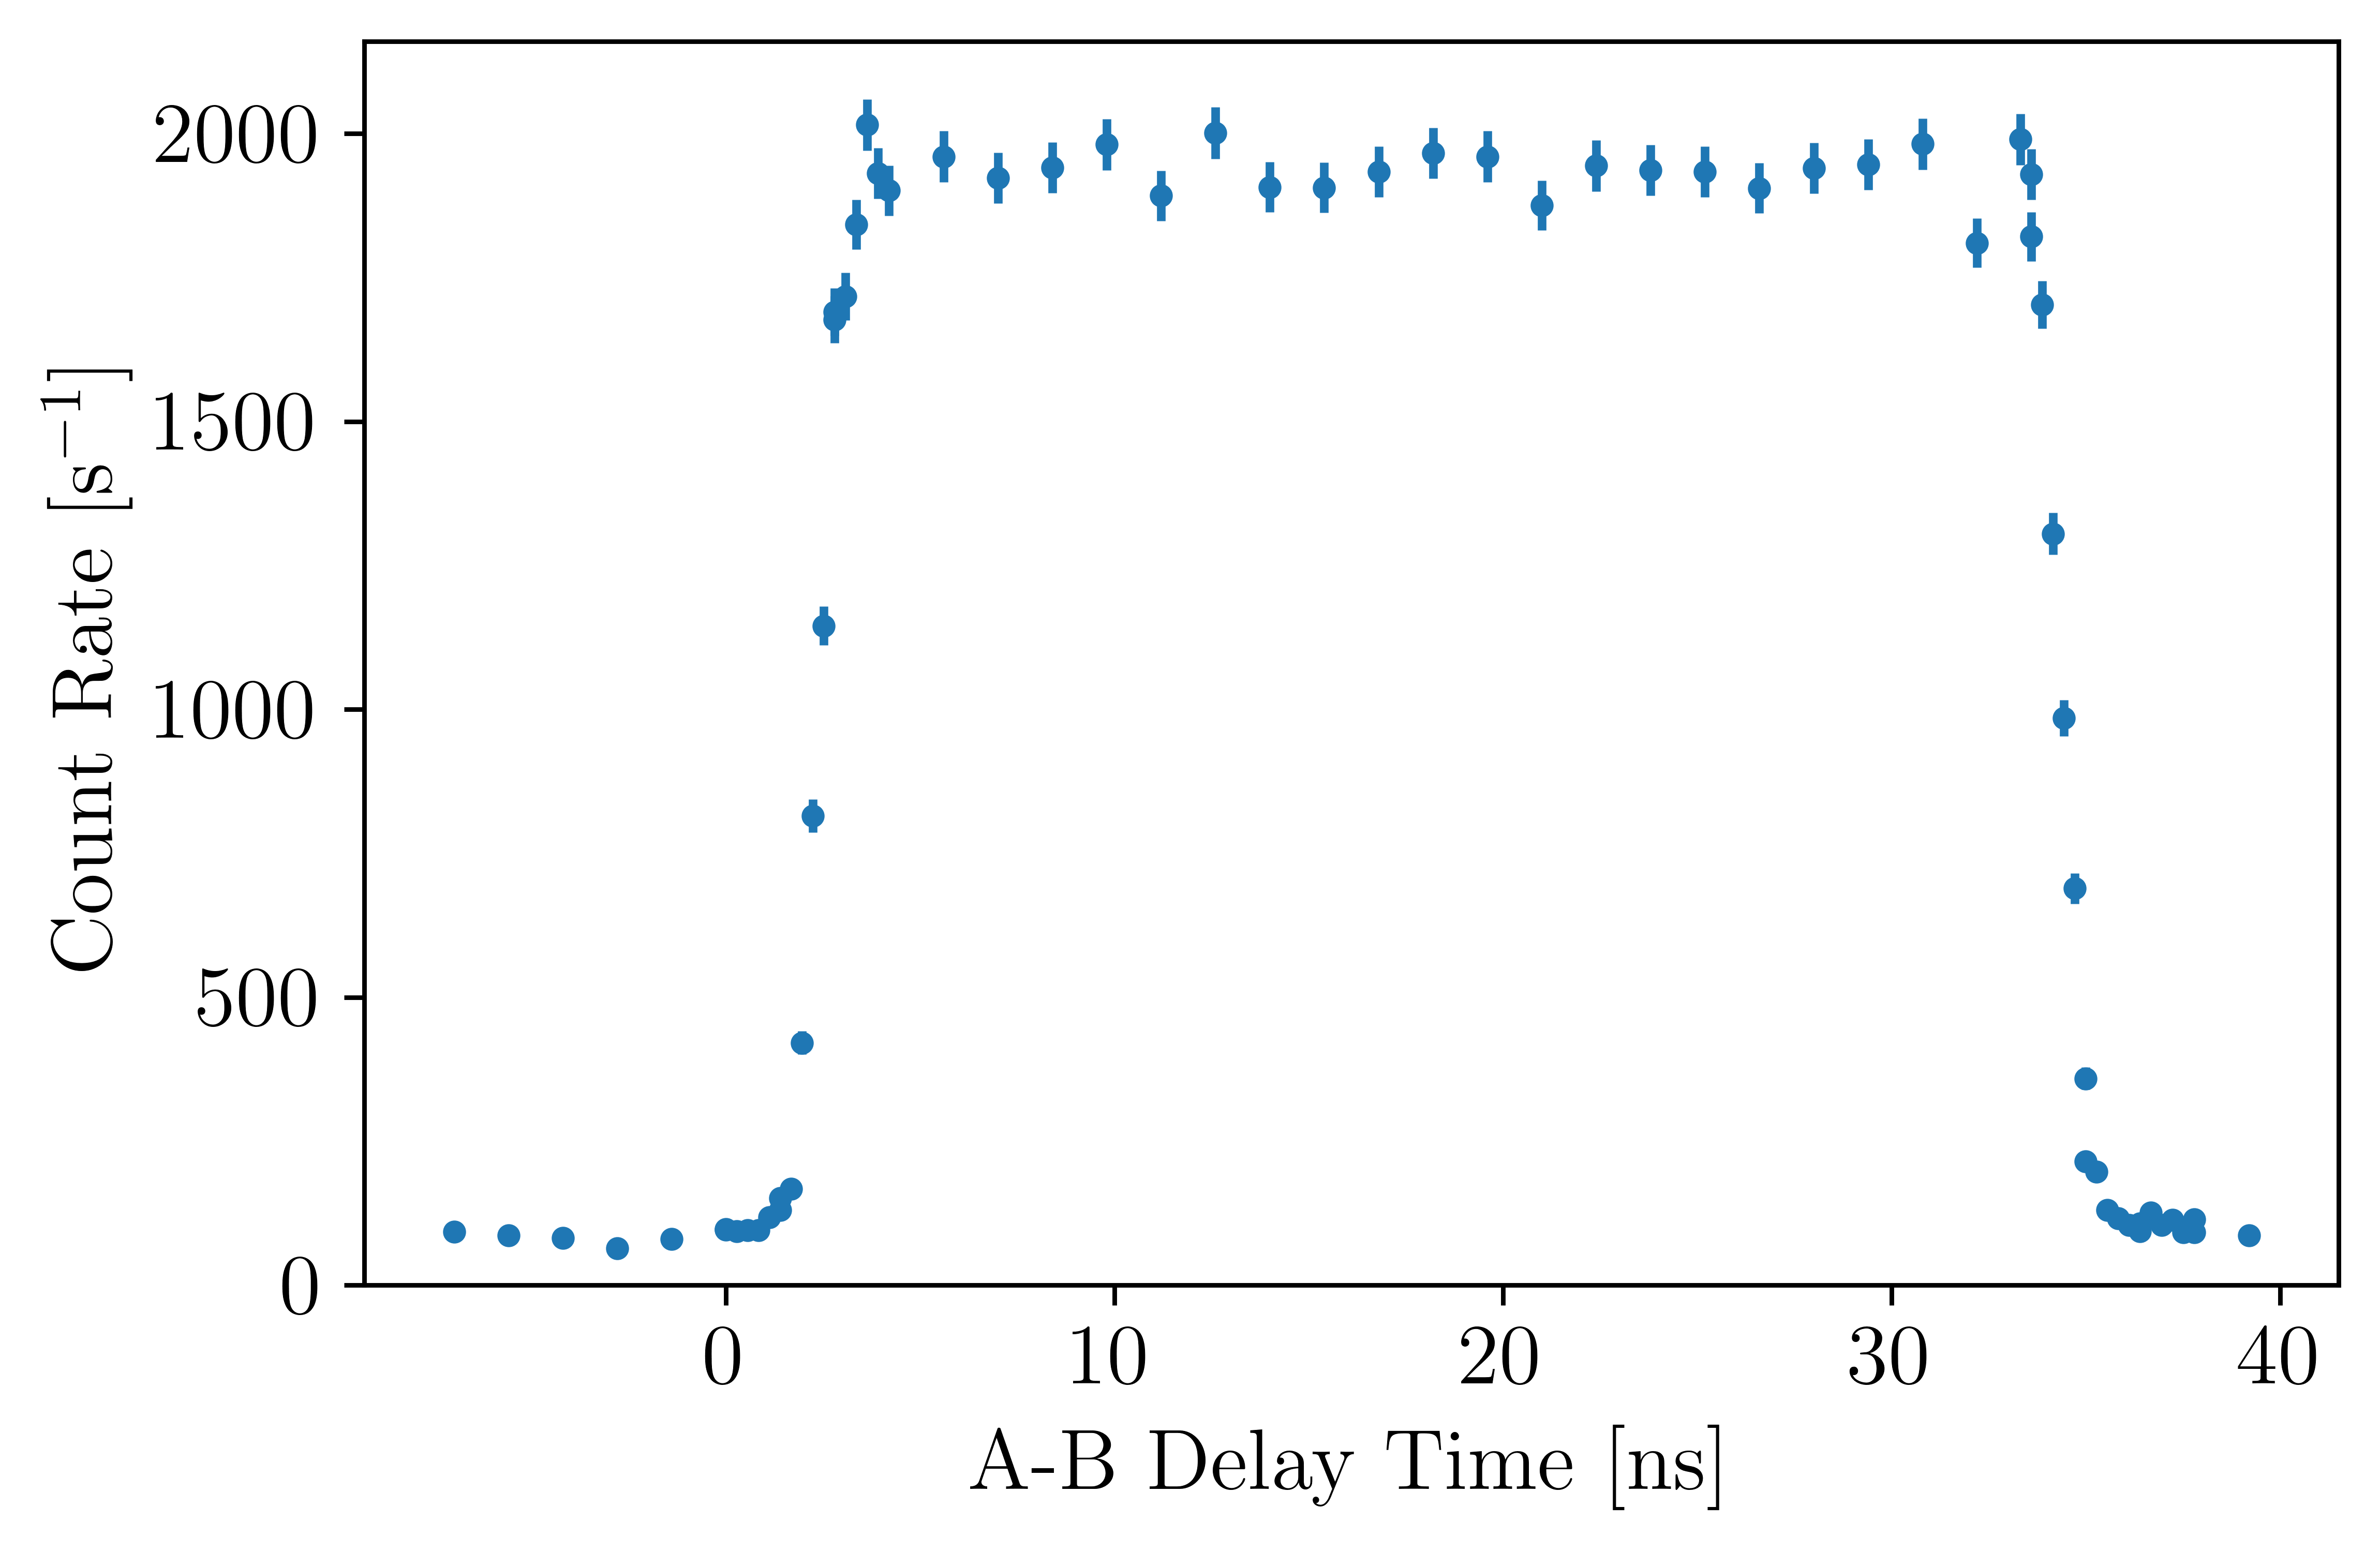

In [9]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=800)
# ax.plot(tau, N, color='black', alpha=1)
ax.errorbar(tau, N, np.sqrt(N), ls='', marker='.')
ax.set_xlabel('A-B Delay Time [ns]')
ax.set_ylabel('Count Rate [s$^{-1}$]')
ax.set_ylim(bottom=0);
fig.tight_layout()
fig.savefig('../figures/tau_data.png', dpi=800)

In [6]:
def smooth_step(x, tau, delta, A, b, k=10.0):
    left  = 1.0 / (1.0 + np.exp(-k * (x - (tau - delta))))
    right = 1.0 / (1.0 + np.exp(-k * (x - (tau + delta))))
    return b + A * (left - right)

In [7]:
p0 = [15, 18, 2 * 1000, 0.05 * 1000, 100]
mu, X = curve_fit(smooth_step, tau, N,
                 bounds = ([8, 10, 0.01 * 1000, 0.01 * 1000, 1],[25, 25, 3 * 1000, 0.25 * 1000, 100]),
                 p0 = p0,
                 sigma = np.sqrt(N))

/var/folders/v9/czyc2p85057bkq0_b7k6tp2r0000gn/T/ipykernel_94893/3502345319.py:3: RuntimeWarning: overflow encountered in exp
  right = 1.0 / (1.0 + np.exp(-k * (x - (tau + delta))))


In [8]:
np.sum((smooth_step(tau, *mu) - N)**2)/1000000


np.float64(0.143705469666488)

Text(0, 0.5, 'Counts')

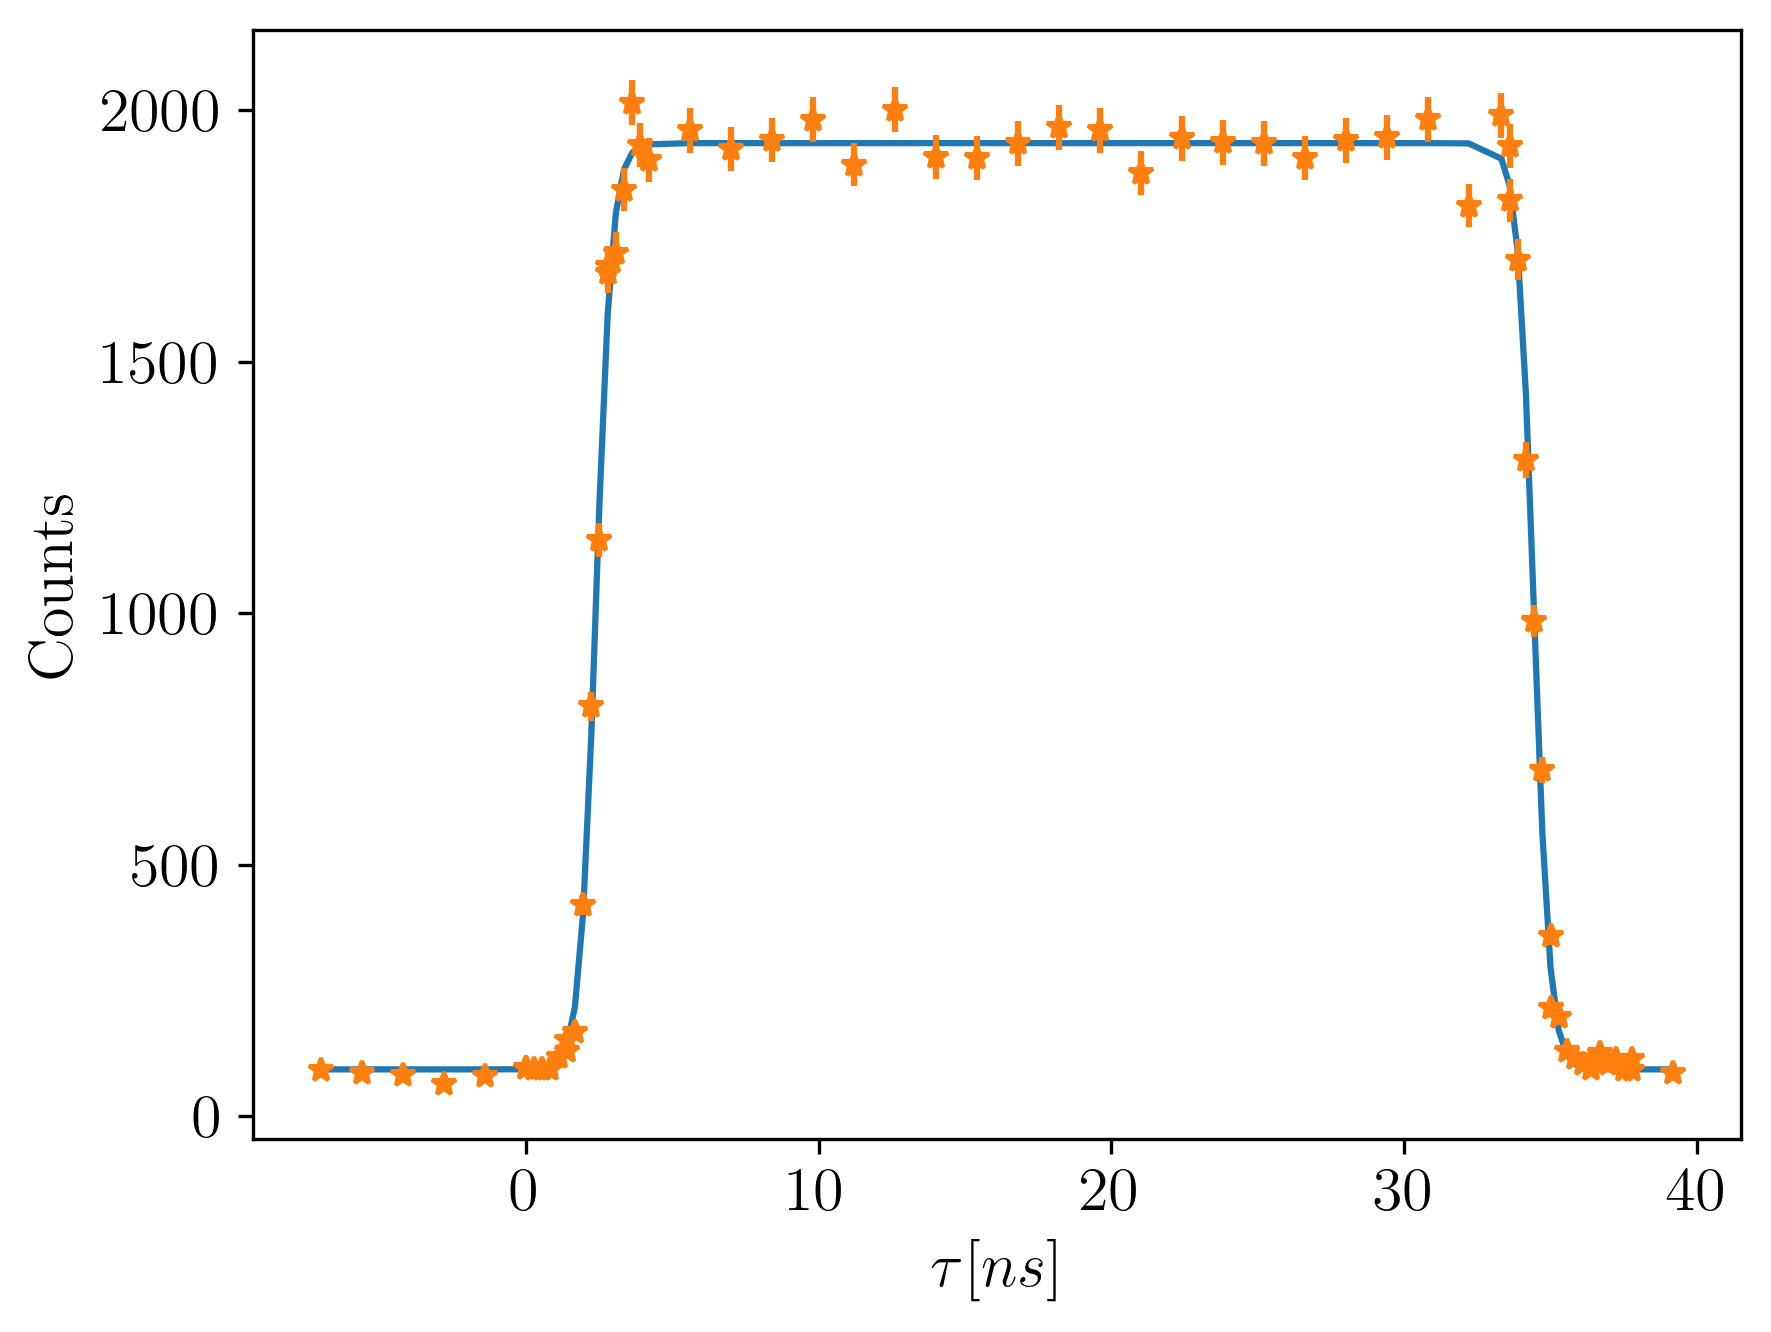

In [ ]:
fig, ax = plt.subplots(dpi = 300)
ax.plot(tau, smooth_step(tau, *mu))
ax.errorbar(tau, N, np.sqrt(N), marker = "*", ls = "None")
ax.set_xlabel("$\\tau [ns]$")
ax.set_ylabel("Counts")


In [14]:
mu

array([  18.41258281,   16.01734805, 1841.38357062,   93.32161303,
          3.67214497])

In [ ]:
#95% confidence interval
np.sqrt(np.diag(X)) * 2

array([2.45362016e-02, 3.10685937e-02, 3.18633581e+01, 7.40308623e+00,
       2.65071553e-01])